In [1]:
# pip install skforecast
# pip install "statsmodels>=0.12, <0.15"
# pip install shap

# Data manipulation
# ==============================================================================
import numpy as np
import pandas as pd
from skforecast.datasets import fetch_dataset

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 10

# Modeling and Forecasting
# ==============================================================================
import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import skforecast
from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold, grid_search_forecaster, backtesting_forecaster
from skforecast.preprocessing import RollingFeatures
from skforecast.utils import save_forecaster, load_forecaster
from skforecast.metrics import calculate_coverage
from skforecast.plot import plot_prediction_intervals
import shap

# Warnings configuration
# ==============================================================================
import warnings
warnings.filterwarnings('once')

color = '\033[1m\033[38;5;208m' 
print(f"{color}Version skforecast: {skforecast.__version__}")
print(f"{color}Version scikit-learn: {sklearn.__version__}")
print(f"{color}Version pandas: {pd.__version__}")
print(f"{color}Version numpy: {np.__version__}")

c:\Users\tuomas.valtanen\introtoml2026lectures\IntroductionToML2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Version skforecast: 0.21.0
Version scikit-learn: 1.7.2
Version pandas: 2.3.3
Version numpy: 2.3.5


In [2]:
# Data download
# ==============================================================================
data = pd.read_csv("RSCCASN.csv")
data

,DATE,RSCCASN
0,1992-01-01,6938.0
1,1992-02-01,7524.0
2,1992-03-01,8475.0
3,1992-04-01,9401.0
4,1992-05-01,9558.0
...,...,...
381,2023-10-01,24438.0
382,2023-11-01,29150.0
383,2023-12-01,41187.0
384,2024-01-01,19420.0


In [ ]:
# reload data 
data = pd.read_csv("RSCCASN.csv")

# filter the first years, to exclude COVID-19 times (see bottom for more explanation)
data = data.iloc[0:336]

# let's modify the dataset so that it follows the original tutorial data
scaler = MinMaxScaler()
data[["RSCCASN"]] = scaler.fit_transform(data[["RSCCASN"]])
data

# scaling is ok, now we have to set the DATE to be our index
data['DATE'] = pd.to_datetime(data['DATE'], format="%Y-%m-%d")
data = data.set_index("DATE")
data = data.asfreq("MS")
data = data.sort_index()
data.head(5)

# DATE is now the INDEX of the DataFrame
# and our only column is RSCCASN

,RSCCASN
DATE,
1992-01-01,0.000000
1992-02-01,0.020764
1992-03-01,0.054461
1992-04-01,0.087272
1992-05-01,0.092835


In [4]:
data.index

DatetimeIndex(['1992-01-01', '1992-02-01', '1992-03-01', '1992-04-01',
               '1992-05-01', '1992-06-01', '1992-07-01', '1992-08-01',
               '1992-09-01', '1992-10-01',
               ...
               '2019-03-01', '2019-04-01', '2019-05-01', '2019-06-01',
               '2019-07-01', '2019-08-01', '2019-09-01', '2019-10-01',
               '2019-11-01', '2019-12-01'],
              dtype='datetime64[ns]', name='DATE', length=336, freq='MS')

In [5]:
data.shape

(336, 1)

Train dates : 1992-01-01 00:00:00 --- 2016-03-01 00:00:00  (n=291)
Test dates  : 2016-04-01 00:00:00 --- 2019-12-01 00:00:00  (n=45)


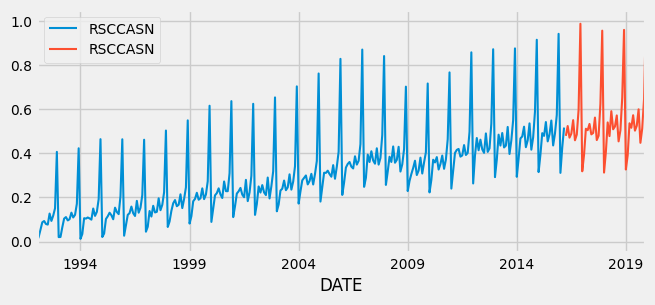

In [6]:
# Data partition train-test
# ==============================================================================
end_train = '2016-03-01 23:59:00'
print(
    f"Train dates : {data.index.min()} --- {data.loc[:end_train].index.max()}  " 
    f"(n={len(data.loc[:end_train])})")
print(
    f"Test dates  : {data.loc[end_train:].index.min()} --- {data.index.max()}  "
    f"(n={len(data.loc[end_train:])})")

# Plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 3))
data.loc[:end_train].plot(ax=ax, label='train')
data.loc[end_train:].plot(ax=ax, label='test')
ax.legend();

In [7]:
# Create and train forecaster
# ==============================================================================
# since this approach is using WINDOWING as the time signal split -strategy
# lags means the step size of the window
# 6 means it moves the window by 6 points instead 1 point at a time

# look at the original tutorial on how to find optimal parameters
forecaster = ForecasterRecursive(
                 regressor = RandomForestRegressor(random_state=123),
                 lags      = 25
             )

forecaster.fit(y=data.loc[:end_train]['RSCCASN'])
forecaster

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_10596\2785118592.py:8: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster = ForecasterRecursive(


=================== 
ForecasterRecursive 
=================== 
Estimator: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25] 
Window features: None 
Window size: 25 
Series name: RSCCASN 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-01-01 00:00:00'), Timestamp('2016-03-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <MonthBegin> 
Estimator parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-04-02 10:07:48 
Last fit date: 2026-04-02 10:07:48 
Skforecast version: 0.21.0 
Python version: 3.12.10 
Forecaster id: None

In [8]:
# Predictions
# ==============================================================================
predictions = forecaster.predict(steps=len(data.loc[end_train:]))
predictions.head(5)

2016-04-01    0.477942
2016-05-01    0.555449
2016-06-01    0.480229
2016-07-01    0.480285
2016-08-01    0.601017
Freq: MS, Name: pred, dtype: float64

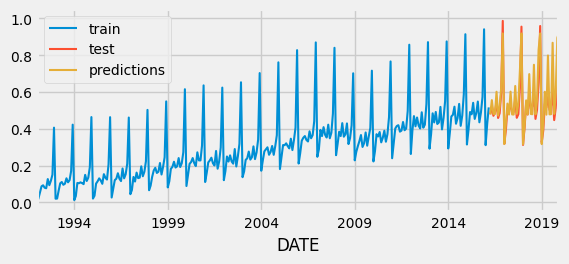

In [9]:
# Plot predictions versus test data
# ==============================================================================
fig, ax = plt.subplots(figsize=(6, 2.5))
data.loc[:end_train]['RSCCASN'].plot(ax=ax, label='train')
data.loc[end_train:]['RSCCASN'].plot(ax=ax, label='test')
predictions.plot(ax=ax, label='predictions')
ax.legend();

In [10]:
# Predict with last window
# ==============================================================================
amount_of_prediction = 120
last_window = data.loc[:end_train][-amount_of_prediction:]['RSCCASN']
future_predictions = forecaster.predict(last_window=last_window, steps=amount_of_prediction)

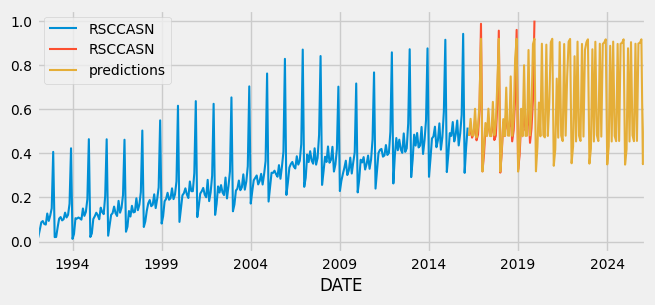

In [11]:
# Plot predictions
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 3))
data.loc[:end_train].plot(ax=ax, label='train')
data.loc[end_train:].plot(ax=ax, label='test')
future_predictions.plot(ax=ax, label='predictions')
ax.legend();

In [12]:
# see what really happened with this data here:
# https://fred.stlouisfed.org/series/RSCCASN

# tip: COVID-19 (which cannot be deduced from this data alone)